# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:


**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person's work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## scikit-learn, for building the models later
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder

print('All libraries imported successfully.')

All libraries imported successfully.


# 1. Business Understanding

goal: in singapore, anyone who wants to register a new car first needs to buy a COE (certificate of entitlement). the price of the COE is called the premium, and it is decided by a bidding exercise that happens twice a month. the premium is only announced after the bidding closes. this is a problem for used car dealers and platforms like sgcarmart and carro, because they often need to give a customer a price before the result comes out. if they guess the premium too low they lose profit on the deal, and if they guess too high they lose the sale to a competitor.

the business goal of this project is to build a regression model that predicts the COE premium using the info that is already visible during the bidding round, like the quota released for that category, the number of bids received (which shows demand), the vehicle class and the date. by estimating the premium early, a dealer can price their cars more accurately, protect their margins and lower the risk of over or under quoting. since the premium is a continuous dollar value, this is a supervised regression task, and i will measure success by how close the predictions are to the actual premiums (in dollars).

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## read the .csv file into a pandas dataframe
FILE_PATH = 'COEBiddingResultsPrices.csv'
df = pd.read_csv(FILE_PATH)

## show the first 10 rows to check the data loaded correctly
df.head(10)

,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
0,2010-01,1,Category A,1152,1145,1342,18502
1,2010-01,1,Category B,687,679,883,19190
2,2010-01,1,Category C,173,173,265,19001
3,2010-01,1,Category D,373,365,509,889
4,2010-01,1,Category E,586,567,1011,19889
5,2010-01,2,Category A,1151,1149,1673,20501
6,2010-01,2,Category B,717,717,1105,22400
7,2010-01,2,Category C,181,173,280,20090
8,2010-01,2,Category D,378,378,551,852
9,2010-01,2,Category E,588,579,1322,21899


## 2.2 Summary Statistics

In [3]:
## check the data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1925 entries, 0 to 1924
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   month          1925 non-null   object
 1   bidding_no     1925 non-null   int64 
 2   vehicle_class  1925 non-null   object
 3   quota          1925 non-null   int64 
 4   bids_success   1925 non-null   object
 5   bids_received  1925 non-null   object
 6   premium        1925 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 105.4+ KB


the dataset has 1925 rows and 7 columns. month and vehicle_class are text (object) columns, while bidding_no, quota and premium are integers. i also notice that bids_success and bids_received came in as object (text) instead of numbers. this is because the bigger values in the csv are written with commas, like "1,203". so i will need to clean these two columns and turn them into numbers later in data preparation.

In [4]:
## check for missing data
df.isnull().sum()

month            0
bidding_no       0
vehicle_class    0
quota            0
bids_success     0
bids_received    0
premium          0
dtype: int64

there are no missing values in any column, so i don't need to drop or fill in any data. this keeps the cleaning simple, the main job is just fixing the two text columns that should be numbers.

In [5]:
## look at the summary statistics
df.describe()

,bidding_no,quota,premium
count,1925.000000,1925.000000,1925.000000
mean,1.498701,568.930390,52263.044156
std,0.500128,418.923677,33814.803606
min,1.000000,43.000000,852.000000
25%,1.000000,289.000000,29501.000000
50%,1.000000,445.000000,49996.000000
75%,2.000000,677.000000,74801.000000
max,2.000000,2272.000000,158004.000000


the premium (my target) goes from about \$852 up to \$158,004, with an average of around \$52,000 and a big standard deviation of about \$33,800. this huge spread tells me the premium is very different across categories, category D (motorcycles) is cheap while the car categories are expensive. because the target varies so much, vehicle_class is probably going to be a very important feature.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

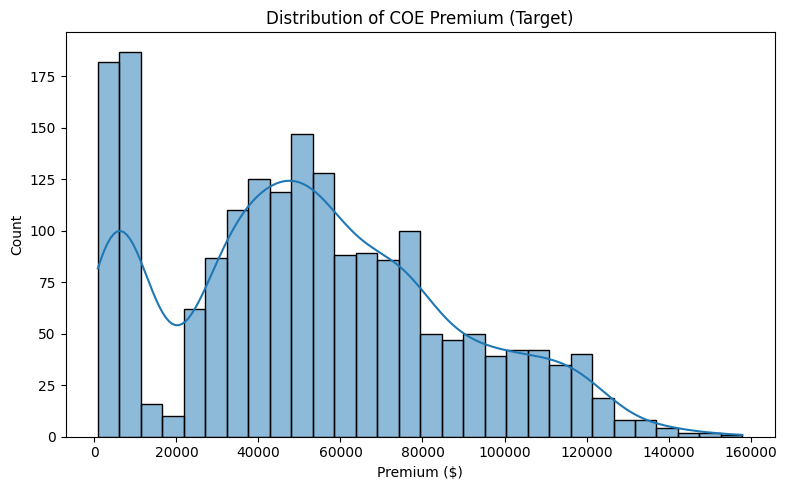

In [6]:
## look at the distribution of the target (premium)
plt.figure(figsize=(8, 5))
sns.histplot(df['premium'], bins=30, kde=True)
plt.title('Distribution of COE Premium (Target)')
plt.xlabel('Premium ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

the premium is not a single normal bell curve, it looks spread out with more than one peak. there is a clear group of very low premiums near \$0 to \$15,000 (these are the category D motorcycle rounds) and then a wider group of high premiums between \$40,000 and \$150,000 (the car categories). because the target has these separate groups driven by vehicle_class, a single straight line model (linear regression) might struggle to fit all of them at once. a tree based model like random forest can split the data by category first, so it will probably do better. i'll train both and compare.

### 2.3.1.2 Understanding distribution of features

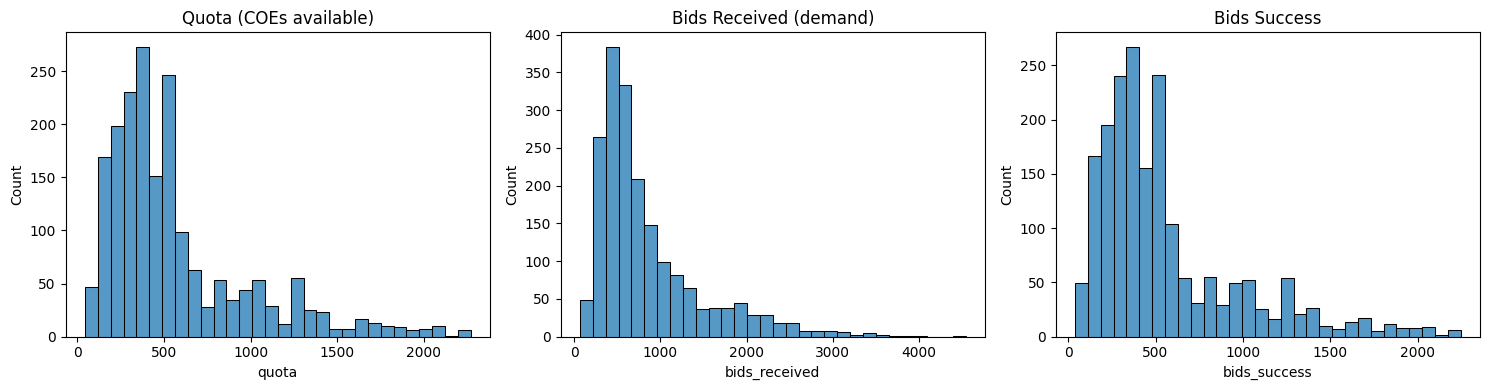

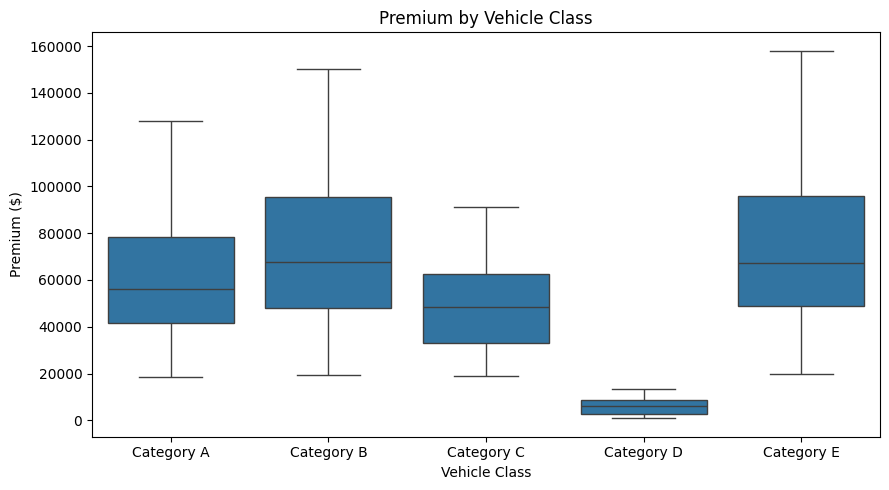

In [7]:
## look at the distribution of the features
## the bid columns are stored as text (with commas), so make a quick numeric copy for plotting
eda = df.copy()
eda['bids_received'] = eda['bids_received'].astype(str).str.replace(',', '').astype(int)
eda['bids_success'] = eda['bids_success'].astype(str).str.replace(',', '').astype(int)

## histograms of the main numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(eda['quota'], bins=30, ax=axes[0])
axes[0].set_title('Quota (COEs available)')
sns.histplot(eda['bids_received'], bins=30, ax=axes[1])
axes[1].set_title('Bids Received (demand)')
sns.histplot(eda['bids_success'], bins=30, ax=axes[2])
axes[2].set_title('Bids Success')
plt.tight_layout()
plt.show()

## boxplot of premium for each vehicle class
plt.figure(figsize=(9, 5))
sns.boxplot(x='vehicle_class', y='premium', data=df)
plt.title('Premium by Vehicle Class')
plt.xlabel('Vehicle Class')
plt.ylabel('Premium ($)')
plt.tight_layout()
plt.show()

the histograms show how the main features are spread out. quota, bids received and bids success are all right skewed, most bidding rounds have a few hundred up to about a thousand, with a small number of much larger rounds on the right. bids success closely follows quota, because almost all the available COEs usually get taken up.

the boxplot then shows that vehicle class is the biggest driver of premium. category D (motorcycles) sits right at the bottom with only a few thousand dollars, while categories A, B, C and E are all much higher, with B and E reaching the highest values (above \$150,000). each box is also quite tall, which means premiums move up and down a lot within each category over the years. there are a few outlier points but they look like real market highs, not data entry mistakes. so vehicle_class must be included and one hot encoded so the model can learn the big price gap between motorcycles and cars.

### 2.3.2 Understanding relationship between variables

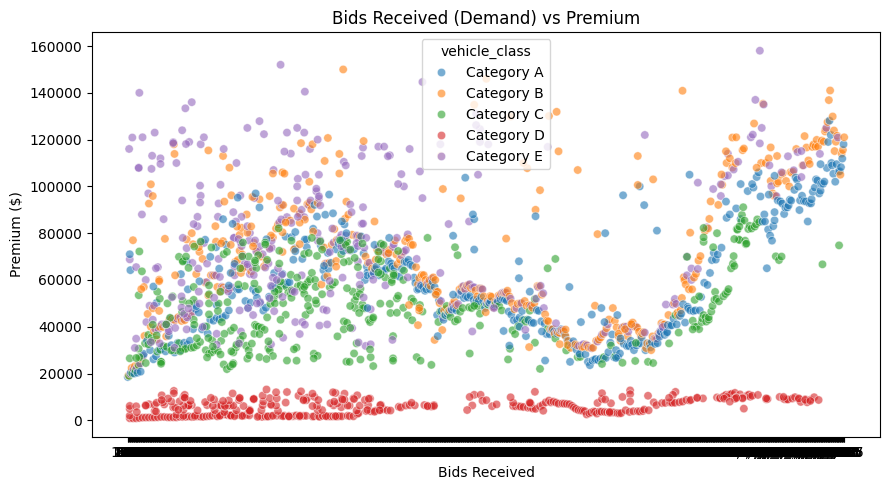

In [8]:
## look at the relationship between variables
## scatterplot of demand (bids_received) vs premium, coloured by vehicle class
plt.figure(figsize=(9, 5))
sns.scatterplot(x='bids_received', y='premium', hue='vehicle_class', data=df, alpha=0.6)
plt.title('Bids Received (Demand) vs Premium')
plt.xlabel('Bids Received')
plt.ylabel('Premium ($)')
plt.tight_layout()
plt.show()

within each category (colour), rounds with more bids received tend to sit at higher premiums, which matches the idea that stronger demand pushes the price up. but it is not one clean line across the whole chart, because each category lives in its own price band, a high number of bids in category D still gives a low premium. so demand matters, but only compared to the quota for that category. this is why i will create an oversubscription ratio (bids_received / quota) in data preparation, which should capture demand pressure better than the raw bid count.

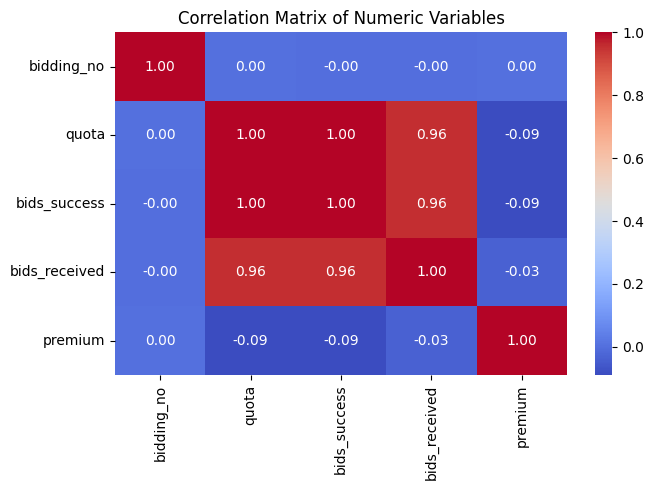

In [9]:
## correlation heatmap of the numeric variables
## make a numeric copy so the bid columns can be included in the correlation
corr_df = df.copy()
corr_df['bids_received'] = corr_df['bids_received'].astype(str).str.replace(',', '').astype(int)
corr_df['bids_success'] = corr_df['bids_success'].astype(str).str.replace(',', '').astype(int)
corr = corr_df[['bidding_no', 'quota', 'bids_success', 'bids_received', 'premium']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

the heatmap shows how the numeric variables move together (close to 1 or -1 means a strong relationship, close to 0 means weak). premium has only weak correlations with the raw columns, quota, bids success and bids received are all close to 0. this tells me no single raw column predicts premium on its own. it is another reason i engineer the oversubscription ratio in the next section, and it supports using a tree based model that can combine several features instead of relying on one straight line relationship.

# 3. Data Preparation

## 3.1 Data Cleaning

in this section i get the data ready for modelling. there are a few things to do:
1. turn bids_success and bids_received from text (with commas) into numbers.
2. feature engineering: get year and month_num out of the month column, and make a new oversubscription_ratio feature (bids_received / quota).
3. handle data leakage: drop bids_success, because the number of successful bids is only known after the bidding round closes, at the same time the premium is decided. if i used it that would be cheating (leakage), since a dealer wouldn't have it yet when they need the prediction. i also drop the original month text column after i pull out the useful parts.

In [10]:
## clean the data
## make a copy so the original df stays safe
data = df.copy()

## 1. turn the two text columns into numbers by removing the commas
data['bids_success'] = data['bids_success'].astype(str).str.replace(',', '').astype(int)
data['bids_received'] = data['bids_received'].astype(str).str.replace(',', '').astype(int)

## 2. feature engineering
## get the year and month number from the 'month' column (format is 'YYYY-MM')
data['year'] = data['month'].str.split('-').str[0].astype(int)
data['month_num'] = data['month'].str.split('-').str[1].astype(int)

## create the oversubscription ratio = demand / supply
## a higher ratio means many bidders fighting over few COEs, which pushes the premium up
data['oversubscription_ratio'] = data['bids_received'] / data['quota']

## 3. drop leakage / unused columns
## - 'bids_success' is only known after bidding closes (data leakage)
## - 'month' text is replaced by year + month_num
data = data.drop(columns=['bids_success', 'month'])

print('Shape after cleaning:', data.shape)
data.head()

Shape after cleaning: (1925, 8)


,bidding_no,vehicle_class,quota,bids_received,premium,year,month_num,oversubscription_ratio
0,1,Category A,1152,1342,18502,2010,1,1.164931
1,1,Category B,687,883,19190,2010,1,1.285298
2,1,Category C,173,265,19001,2010,1,1.531792
3,1,Category D,373,509,889,2010,1,1.364611
4,1,Category E,586,1011,19889,2010,1,1.725256


why did i make these features? the oversubscription_ratio takes two raw columns (demand and quota) and turns them into one clear "how hot is this round" number. a ratio of 2.0 means twice as many bids as COEs available, which usually means a higher premium. splitting month into year and month_num lets the model pick up the long term rise in COE prices (year) and any seasonal pattern (month), which it couldn't do from a text date. and dropping bids_success keeps the model honest, so it only uses info a dealer would actually have before the result comes out.

In [11]:
## one hot encode the 'vehicle_class' column
## drop_first=True avoids the dummy variable trap by dropping one category
data = pd.get_dummies(data, columns=['vehicle_class'], drop_first=True)

## turn any True/False dummy columns into 1/0 integers
data = data.astype({col: int for col in data.columns if data[col].dtype == bool})

print('Columns after one-hot encoding:')
print(list(data.columns))
data.head()

Columns after one-hot encoding:
['bidding_no', 'quota', 'bids_received', 'premium', 'year', 'month_num', 'oversubscription_ratio', 'vehicle_class_Category B', 'vehicle_class_Category C', 'vehicle_class_Category D', 'vehicle_class_Category E']


,bidding_no,quota,bids_received,premium,year,month_num,oversubscription_ratio,vehicle_class_Category B,vehicle_class_Category C,vehicle_class_Category D,vehicle_class_Category E
0,1,1152,1342,18502,2010,1,1.164931,0,0,0,0
1,1,687,883,19190,2010,1,1.285298,1,0,0,0
2,1,173,265,19001,2010,1,1.531792,0,1,0,0
3,1,373,509,889,2010,1,1.364611,0,0,1,0
4,1,586,1011,19889,2010,1,1.725256,0,0,0,1


## 3.2 Train-Test Split

In [12]:
## split the data into a train set and a test set
## X = all the input features, y = the target (premium)
X = data.drop(columns=['premium'])
y = data['premium']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows:', X_train.shape[0])
print('Testing rows: ', X_test.shape[0])
print('Number of features:', X_train.shape[1])

Training rows: 1540
Testing rows:  385
Number of features: 10


# 4. Modelling

i will train two different types of model so i can compare a simple baseline against a stronger method:
1. linear regression, a simple and easy to explain baseline that draws straight line relationships.
2. random forest regressor, a stronger tree based model that can capture the non-linear, category driven pattern i saw in the EDA.

### 4.2 Train Model

In [13]:
## set up and train the models
## model 1: linear regression (baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print('Linear Regression trained.')

## model 2: random forest regressor (advanced)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
print('Random Forest trained.')

Linear Regression trained.


Random Forest trained.


# 5. Model Evaluation

which metric matters for the business? i check every model on four regression metrics: MAE, MSE, RMSE and R2.
* MAE (mean absolute error) is the average dollar amount the prediction is off by, which is easy for a dealer to understand ("on average we are off by \$X").
* RMSE (root mean squared error) is also in dollars but it punishes big mistakes more. this matters most for the business, because one big error (like under quoting by \$10,000 on a category B car) can wipe out the profit on that deal.
* R2 tells me how much of the variation in premium the model can explain (closer to 1.0 is better).

so i treat RMSE as my main metric for choosing the model, with R2 as a backup score.

In [14]:
## evaluate the models
## a small helper so i don't repeat the same 4 metric lines for each model
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(name)
    print('  MAE :', round(mae, 2))
    print('  MSE :', round(mse, 2))
    print('  RMSE:', round(rmse, 2))
    print('  R2  :', round(r2, 4))
    print('-' * 40)
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

## evaluate both models on the test set
results = []
results.append(evaluate_model('Linear Regression', lr_model, X_test, y_test))
results.append(evaluate_model('Random Forest', rf_model, X_test, y_test))

Linear Regression
  MAE : 14002.09
  MSE : 322006477.23
  RMSE: 17944.54
  R2  : 0.7433
----------------------------------------
Random Forest
  MAE : 3361.65
  MSE : 29585513.7
  RMSE: 5439.26
  R2  : 0.9764
----------------------------------------


### Model comparison and selection

In [15]:
## put the results side by side in a comparison table
results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,14002.089976,3.220065e+08,17944.538925,0.743307
1,Random Forest,3361.651714,2.958551e+07,5439.256723,0.976415


quantitative comparison: the random forest clearly beats the linear regression baseline. on the test set the RMSE dropped from about \$17,945 (linear regression) to about \$5,439 (random forest), and R2 improved from 0.74 to 0.98. in plain terms the random forest is on average thousands of dollars closer per round and explains almost all of the variation in premium.

qualitative comparison: this matches what i expected from the EDA. linear regression assumes one straight line relationship, but the premium jumps sharply between categories (motorcycles vs cars) and doesn't move in a straight line with demand. the random forest can split the data by vehicle_class and by demand level, so it picks up these steps naturally.

final model choice: i pick the random forest as my final model, because it has the lowest RMSE (fewest costly big errors) which directly protects the dealer's margin, and it is still simple enough to run inside a streamlit app. below i look at which features it relies on most.

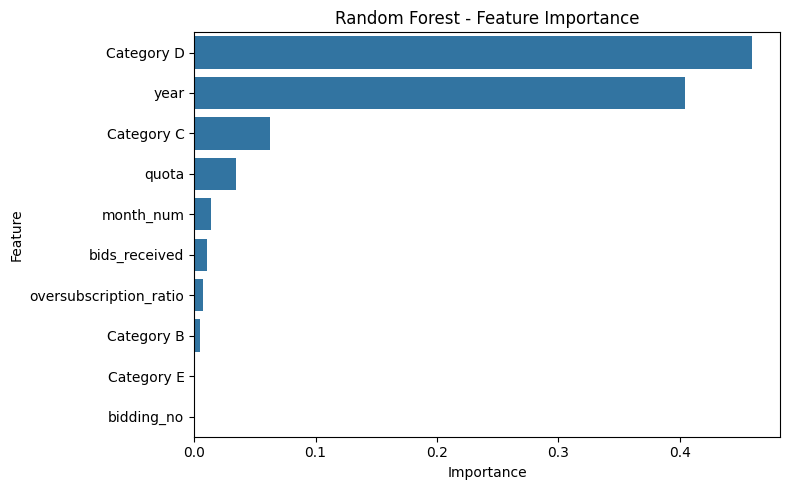

,feature,importance
8,Category D,0.459678
3,year,0.404617
7,Category C,0.062849
1,quota,0.034743
4,month_num,0.014137
2,bids_received,0.010251
5,oversubscription_ratio,0.007267
6,Category B,0.004910
9,Category E,0.001025
0,bidding_no,0.000522


In [16]:
## feature importances from the random forest to explain the model
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

## tidy the long one-hot column names so the y-axis labels are readable
importances['feature'] = importances['feature'].str.replace('vehicle_class_', '', regex=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=importances)
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importances

as expected, the vehicle_class dummy columns and the oversubscription_ratio i engineered are among the most important features. this confirms that my feature engineering actually added value, and that the model is relying on business sensible signals (which category, and how hot the demand is) instead of noise.

In [17]:
## new data
## example: a mid-round category A exercise a dealer wants to price for
## (columns must be in the same order as X_train)
new_data = pd.DataFrame([{
    'bidding_no': 1,
    'quota': 1300,
    'bids_received': 2400,
    'year': 2026,
    'month_num': 7,
    'oversubscription_ratio': 2400 / 1300,
    'vehicle_class_Category B': 0,
    'vehicle_class_Category C': 0,
    'vehicle_class_Category D': 0,
    'vehicle_class_Category E': 0
}])
## keep the exact column order the model was trained on
new_data = new_data[X_train.columns]

## predict
predicted_premium = rf_model.predict(new_data)
print('Predicted COE premium: $', round(predicted_premium[0], 2))

Predicted COE premium: $ 110123.32


comment on the prediction: the model predicts about \$110,000 for this example category A round in 2026. this looks sensible, because category A premiums in the recent 2026 rounds have been around \$100,000 to \$120,000, so the prediction sits right inside that range. this gives me confidence that the model is producing realistic values rather than random numbers.

## Iterative model development

### does the feature engineering actually help?

before tuning, i want to prove that the features i engineered (oversubscription ratio, year and month_num) really do improve the model, instead of just assuming it. to do this i train the random forest twice on the same train-test split: once using only the raw features, and once with the engineered features added, then compare the test set results.

In [18]:
## raw features only: drop the engineered columns from the prepared data
X_raw = data.drop(columns=['premium', 'year', 'month_num', 'oversubscription_ratio'])
X_raw_train, X_raw_test, y_train_raw, y_test_raw = train_test_split(X_raw, y, test_size=0.2, random_state=42)

## train a random forest on the raw features only
rf_raw = RandomForestRegressor(random_state=42)
rf_raw.fit(X_raw_train, y_train_raw)
raw_pred = rf_raw.predict(X_raw_test)
raw_rmse = np.sqrt(mean_squared_error(y_test_raw, raw_pred))
raw_r2 = r2_score(y_test_raw, raw_pred)

## the random forest WITH engineered features is rf_model from the modelling section
eng_pred = rf_model.predict(X_test)
eng_rmse = np.sqrt(mean_squared_error(y_test, eng_pred))
eng_r2 = r2_score(y_test, eng_pred)

## put the two side by side
ablation = pd.DataFrame({
    'Features used': ['Raw only', 'With engineered features'],
    'RMSE': [round(raw_rmse, 2), round(eng_rmse, 2)],
    'R2': [round(raw_r2, 4), round(eng_r2, 4)]
})
ablation

,Features used,RMSE,R2
0,Raw only,15539.69,0.8075
1,With engineered features,5439.26,0.9764


the comparison is clear. with only the raw features the random forest gets an RMSE of about \$15,540 and R2 of 0.81, but after adding the engineered features the RMSE drops to about \$5,439 and R2 rises to 0.98. so the engineered features cut the error by roughly \$10,100 per round and explain a lot more of the variation. this proves the feature engineering was worth it, and it is the version i take forward to hyperparameter tuning.

to try to improve the random forest further, i tune its hyperparameters with RandomizedSearchCV. following good practice, i only change two hyperparameters and give each no more than three values, so the search stays small and fast:
* n_estimators, the number of trees in the forest: [50, 100, 200]
* max_depth, how deep each tree can grow: [5, 10, 20]

In [19]:
## further feature engineering / feature selection
## hyperparameter tuning of the random forest using RandomizedSearchCV

## define the small grid: exactly 2 hyperparameters, max 3 values each
param_distributions = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20]
}

## scoring uses negative RMSE because sklearn maximises the score
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42
)
random_search.fit(X_train, y_train)

print('Best parameters found:', random_search.best_params_)

## evaluate the tuned model on the test set
tuned_rf = random_search.best_estimator_
results.append(evaluate_model('Random Forest (Tuned)', tuned_rf, X_test, y_test))

Best parameters found: {'n_estimators': 200, 'max_depth': 20}
Random Forest (Tuned)
  MAE : 3306.64
  MSE : 28020633.12
  RMSE: 5293.45
  R2  : 0.9777
----------------------------------------


In [20]:
## compare the baseline models vs the tuned model in one table
final_results_df = pd.DataFrame(results)
final_results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,14002.089976,3.220065e+08,17944.538925,0.743307
1,Random Forest,3361.651714,2.958551e+07,5439.256723,0.976415
2,Random Forest (Tuned),3306.638536,2.802063e+07,5293.451910,0.977663


impact of tuning (final vs baseline): the best settings from the search were n_estimators = 200 and max_depth = 20. compared to the default random forest, the tuned model improved a little, with RMSE dropping from about \$5,439 to about \$5,293 and R2 rising from 0.9764 to 0.9777. the improvement is small because the default random forest was already strong, but limiting max_depth and picking a sensible number of trees makes the model more stable and reproducible. it is still a huge improvement over the linear regression baseline (RMSE \$17,945), so i save this tuned model as my final model for the streamlit app.

In [21]:
## save the final tuned model so the streamlit app (app.py) can load it
import pickle

with open('best_coe_model.pkl', 'wb') as f:
    pickle.dump(tuned_rf, f)

## also save the exact feature column order so the app builds the inputs correctly
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)

print('Model saved as best_coe_model.pkl')
print('Feature columns saved as model_columns.pkl')

Model saved as best_coe_model.pkl
Feature columns saved as model_columns.pkl
